In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

sys.path.insert(0, r"C:\Users\Dell\AppliedML")

from courselib.models.base import TrainableModel
from courselib.optimizers import GDOptimizer
from courselib.utils.metrics import mean_squared_error as mse_metric


In [ ]:
#ReLU activation function and its subgradient
class ReLU:
    def __call__(self, x):
        return np.maximum(0, x)
    def grad(self, x):
        return (x > 0).astype(float)

# Linear activation (identity function) and its derivative
class Linear:
    def __call__(self, x):
        return x
    def grad(self, x):
        return np.ones_like(x)

# Quadratic (L2) loss and its gradient  
class MSE:
    def __call__(self, Y_pred, Y_true):
        return 0.5 * np.mean((Y_pred - Y_true) ** 2)
    def grad(self, Y_pred, Y_true):
        return (Y_pred - Y_true) / Y_pred.shape[0]

In [ ]:
# Fully-connected (dense) layer with activation

class DenseLayer:
    def __init__(self, num_in, num_out, activation=None, layer_name=None):
        self.num_in = num_in
        self.num_out = num_out
        self.activation = activation() if activation else ReLU()
        self.name = layer_name or f"Dense_{num_in}_{num_out}"
        self.W = np.random.normal(0, np.sqrt(2. / num_in), (num_in, num_out))
        self.b = np.zeros((1, num_out))

# Forward pass through the layer
    def __call__(self, X):
        z = X @ self.W + self.b
        x = self.activation(z)
        return z, x
# Compute backpropagated error for this layer
    def compute_delta(self, z, W_next, delta_next):
        return (delta_next @ W_next.T) * self.activation.grad(z)
    
# Compute gradients w.r.t. weights and biases
    def loss_grad(self, X_prev, delta):
        w_grad = np.mean(delta[:, :, None] * X_prev[:, None, :], axis=0).T
        b_grad = np.mean(delta, axis=0, keepdims=True)
        return {f'{self.name}_W': w_grad, f'{self.name}_b': b_grad}

# Return a dictionary of parameters for this layer
    def _get_params(self):
        return {f'{self.name}_W': self.W, f'{self.name}_b': self.b}

In [ ]:
# Define the MLP class to implement the backpropagation algorithm to compute the gradients layer by layer 

class MLP:
    def __init__(self, widths, optimizer, activation=ReLU, output_activation=Linear, loss=MSE):

        """
        Initializes a multi-layer perceptron (MLP) using a sequence of DenseLayers.
        
        Parameters:
        - widths: list of layer sizes, including input and output dimensions
        - optimizer: optimizer instance (must support `update(params, grads)`)
        - activation: activation class for hidden layers
        - output_activation: activation class for the output layer
        - loss: loss function class
        
        """

        self.optimizer = optimizer
        self.widths = widths
        self.loss = loss()

        # Hidden layers
        self.layers = [
            DenseLayer(widths[i], widths[i+1], activation=activation, layer_name=f"layer_{i}")
            for i in range(len(widths) - 2)
        ]
        # Output layer
        self.layers.append(
            DenseLayer(widths[-2], widths[-1], activation=output_activation, layer_name=f"layer_{len(widths)-2}")
        )

    def decision_function(self, X):
        out = X
        for layer in self.layers:
            _, out = layer(out)
        return out

    def forward_pass(self, X):
        x_l = [X]
        z_l = [X]
        for layer in self.layers:
            z, x = layer(x_l[-1])
            z_l.append(z)
            x_l.append(x)
        return z_l, x_l

    def backward_pass(self, X, Y, z_l, x_l):
        delta = self.loss.grad(x_l[-1], Y) * self.layers[-1].activation.grad(z_l[-1])
        deltas = [delta]
        for i in reversed(range(len(self.layers) - 1)):
            delta = self.layers[i].compute_delta(z_l[i+1], self.layers[i+1].W, deltas[-1])
            deltas.append(delta)
        return deltas[::-1]

    def loss_grad(self, X, Y):
        z_l, x_l = self.forward_pass(X)
        delta_l = self.backward_pass(X, Y, z_l, x_l)
        grads = {}
        for i, layer in enumerate(self.layers):
            grads.update(layer.loss_grad(x_l[i], delta_l[i]))
        return grads

    def _get_params(self):
        params = {}
        for layer in self.layers:
            params.update(layer._get_params())
        return params

    def fit(self, X, Y, num_epochs=500, batch_size=256, compute_metrics=False, metrics_dict=None):
        history = {k: [] for k in (metrics_dict or {}).keys()}

        for epoch in range(num_epochs):
            idx = np.random.permutation(len(X))
            for start in range(0, len(X), batch_size):
                batch_idx = idx[start:start + batch_size]
                X_batch = X[batch_idx]
                Y_batch = Y[batch_idx]

                grads = self.loss_grad(X_batch, Y_batch)

                params = {}
                for layer in self.layers:
                    params[f'{layer.name}_W'] = layer.W
                    params[f'{layer.name}_b'] = layer.b

            
                self.optimizer.update(params, grads)

            if compute_metrics and metrics_dict:
                Y_pred = self.decision_function(X)
                for name, fn in metrics_dict.items():
                    history[name].append(fn(Y_pred, Y))

            if epoch % 50 == 0:
                Y_pred = self.decision_function(X)
                print(f"Epoch {epoch} | Loss: {self.loss(Y_pred, Y):.4f}")

        return history

In [5]:
# Converting the given data

df = pd.read_csv(Path("household_power_consumption.txt"), sep=";", na_values="?")
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.dropna(subset=['Global_active_power'])
df = df.set_index('datetime')
df_hourly = df['Global_active_power'].resample('h').mean().dropna().reset_index()
df_hourly.columns = ['datetime', 'power']
df_hourly['hour']        = df_hourly['datetime'].dt.hour
df_hourly['day_of_week'] = df_hourly['datetime'].dt.dayofweek
df_hourly['day_of_year'] = df_hourly['datetime'].dt.dayofyear
print(df_hourly.shape)

(34168, 5)


In [6]:
# Fourier features (same function as before)

def fourier_features(df, K_hour=5, K_week=3, K_year=3):
    features = {}
    for k in range(1, K_hour + 1):
        features[f'sin_hour_{k}'] = np.sin(2 * np.pi * k * df['hour'] / 24)
        features[f'cos_hour_{k}'] = np.cos(2 * np.pi * k * df['hour'] / 24)
    for k in range(1, K_week + 1):
        features[f'sin_week_{k}'] = np.sin(2 * np.pi * k * df['day_of_week'] / 7)
        features[f'cos_week_{k}'] = np.cos(2 * np.pi * k * df['day_of_week'] / 7)
    for k in range(1, K_year + 1):
        features[f'sin_year_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365)
        features[f'cos_year_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365)
    return pd.DataFrame(features, index=df.index)

X = fourier_features(df_hourly).values  # numpy array for the MLP
y = df_hourly['power'].values.reshape(-1, 1)  # shape (N, 1)
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (34168, 22) | y shape: (34168, 1)


In [7]:
# Split the data into training and test sets

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 27334 | Test: 6834


In [8]:
from courselib.optimizers import GDOptimizer

# Use the MLP from the course
optimizer = GDOptimizer(learning_rate=0.001)

model = MLP(
    widths=[X_train.shape[1], 64, 32, 1],  # input -> hidden -> hidden -> output
    optimizer=optimizer,
    activation=ReLU,
    output_activation=Linear,
    loss=MSE
)

metrics_dict = {"loss": mse_metric}

metrics_history = model.fit(
    X_train, y_train,
    num_epochs=500,
    batch_size=256,
    compute_metrics=True,
    metrics_dict=metrics_dict
)

Epoch 0 | Loss: 2.3106
Epoch 50 | Loss: 1.4096
Epoch 100 | Loss: 0.9965
Epoch 150 | Loss: 0.7963
Epoch 200 | Loss: 0.6951
Epoch 250 | Loss: 0.6406
Epoch 300 | Loss: 0.6085
Epoch 350 | Loss: 0.5871
Epoch 400 | Loss: 0.5711
Epoch 450 | Loss: 0.5581


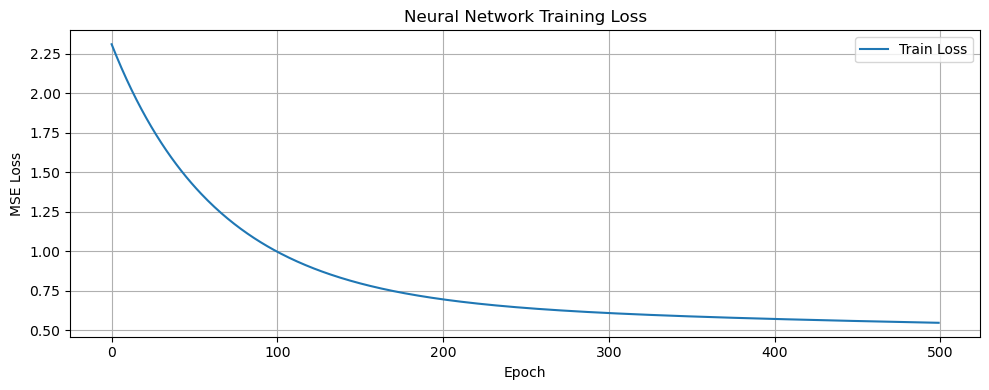

In [9]:
# Plot the training loss over epochs

plt.figure(figsize=(10, 4))
plt.plot(metrics_history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Neural Network Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/nn_training_loss.png')
plt.show()

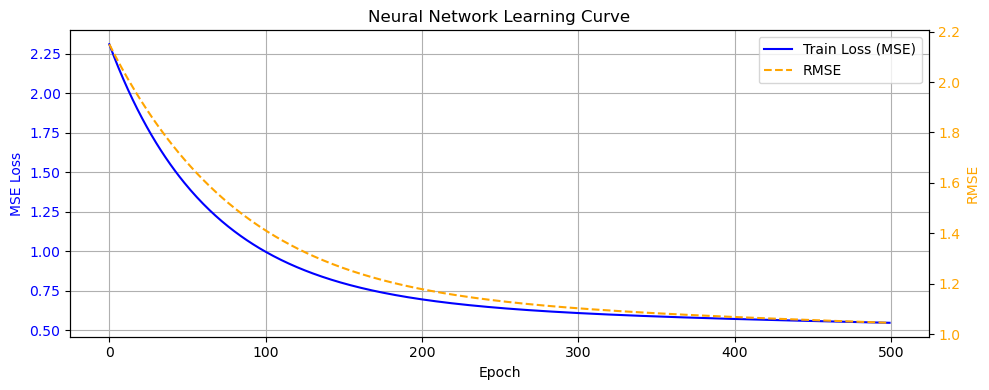

Final Train RMSE: 1.0458


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

# Training loss
ax.plot(metrics_history['loss'], label='Train Loss (MSE)', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# RMSE on second axis
ax2 = ax.twinx()
rmse_per_epoch = [np.sqrt(2 * l) for l in metrics_history['loss']]
ax2.plot(rmse_per_epoch, label='RMSE', color='orange', linestyle='--')
ax2.set_ylabel('RMSE', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax.set_title('Neural Network Learning Curve')
ax.grid(True)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('../figures/nn_learning_curve.png')
plt.show()

print(f"Final Train RMSE: {rmse_per_epoch[-1]:.4f}")

In [11]:
# Evaluate the model on the test set and compare to the Ridge regression

y_pred_nn = model.decision_function(X_test)

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name:15s} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

evaluate("Neural Network", y_test, y_pred_nn)

# Compare with Ridge
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
X_all = fourier_features(df_hourly).values
ridge.fit(X_all[:split], y_test.ravel()[:split] if False else y[:split].ravel())
y_pred_ridge = ridge.predict(X_test)
evaluate("Ridge", y_test.ravel(), y_pred_ridge)

Neural Network  | RMSE: 0.9056 | MAE: 0.7059
Ridge           | RMSE: 0.6396 | MAE: 0.4902


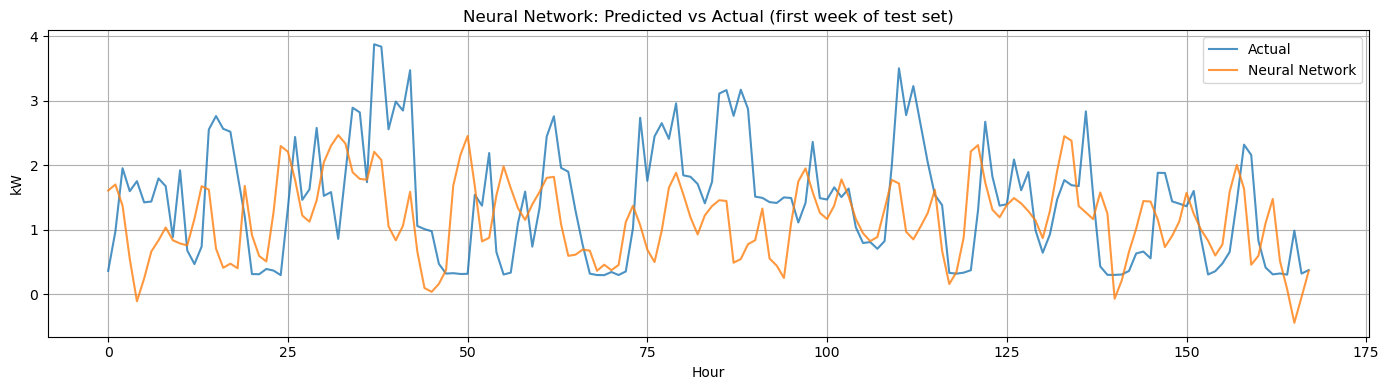

In [12]:
# Predict vs Actual for the first week of the test set

n_plot = 24 * 7  # one week
plt.figure(figsize=(14, 4))
plt.plot(y_test[:n_plot], label='Actual', alpha=0.8)
plt.plot(y_pred_nn[:n_plot], label='Neural Network', alpha=0.8)
plt.title('Neural Network: Predicted vs Actual (first week of test set)')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/nn_predictions_vs_actual.png')
plt.show()

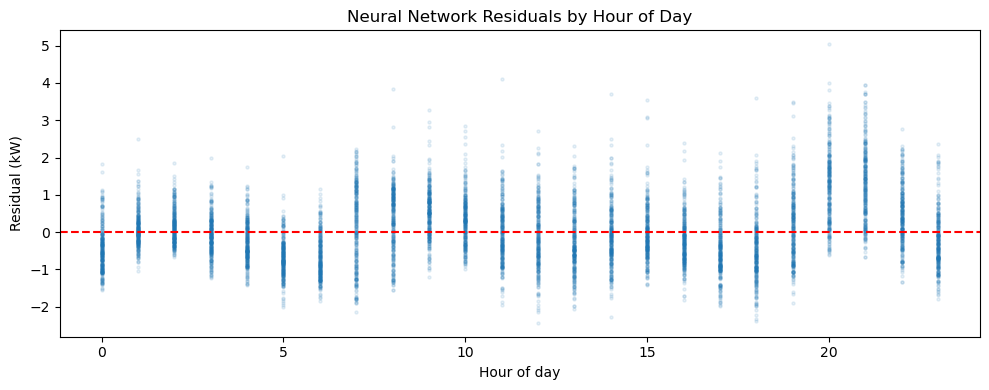

In [13]:
# Residuals by hour of day

residuals_nn = y_test.ravel() - y_pred_nn.ravel()
test_hours = df_hourly['hour'].values[split:]

plt.figure(figsize=(10, 4))
plt.scatter(test_hours, residuals_nn, alpha=0.1, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Hour of day')
plt.ylabel('Residual (kW)')
plt.title('Neural Network Residuals by Hour of Day')
plt.tight_layout()
plt.savefig('../figures/nn_residuals_by_hour.png')
plt.show()